# Simulated Annealing Sampler Demo

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from Qommunity.samplers.regular.simulated_annealing_sampler import SimulatedAnnealingSampler

In [2]:
def run_sampler(G, communities, resolution=1.0, **kwargs):
    sampler = SimulatedAnnealingSampler(
        G,
        communities=communities,
        resolution=resolution,
        **kwargs,
    )
    sample = sampler.sample_qubo_to_dict()
    return {int(node[1:]): int(comm) for node, comm in sample.items()}

def partition_to_list(partition):
    comm_map = {}
    for node, comm in partition.items():
        comm_map.setdefault(comm, []).append(node)
    return [sorted(nodes) for nodes in comm_map.values()]

def calculate_modularity_nx(G, partition, resolution=1.0):
    communities = partition_to_list(partition)
    return nx.algorithms.community.modularity(
        G, [set(nodes) for nodes in communities], resolution=resolution
    )

def visualize_partition(G, partition, title):
    pos = nx.spring_layout(G)
    colors = [partition[node] for node in G.nodes()]
    plt.figure(figsize=(8, 6))
    nx.draw(
        G,
        pos,
        node_color=colors,
        with_labels=True,
        cmap=plt.cm.Set3,
        node_size=500,
        edge_color='gray',
        font_size=10,
        font_weight='bold',
    )
    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Test 1: Karate Club

KARATE CLUB NETWORK
Number of nodes: 34
Number of edges: 78
Modularity: 0.403628
Number of detected communities: 2

Community 0: 16 nodes
  Nodes: [0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21]
Community 1: 18 nodes
  Nodes: [8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]


C:\Users\Kacper\AppData\Local\Temp\ipykernel_24612\1323893553.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


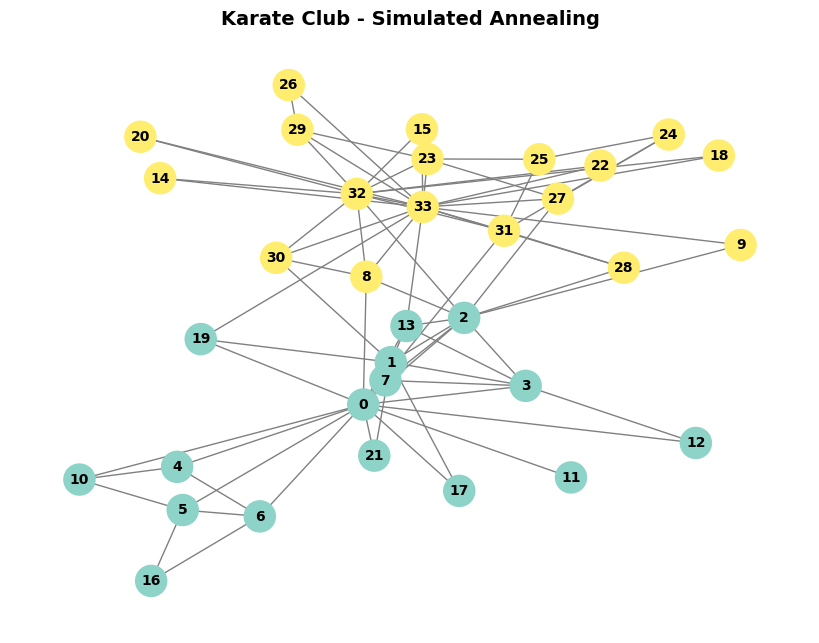

In [3]:
G1 = nx.karate_club_graph()

partition1 = run_sampler(
    G1,
    communities=2,
    resolution=1.0,
    time=30000,
    Tmax=25000,
    Tmin=2.5,
    steps=30000,
    updates=0,
)

modularity1 = calculate_modularity_nx(G1, partition1, resolution=1.0)
communities1 = partition_to_list(partition1)

print("=" * 70)
print("KARATE CLUB NETWORK")
print("=" * 70)
print(f"Number of nodes: {G1.number_of_nodes()}")
print(f"Number of edges: {G1.number_of_edges()}")
print(f"Modularity: {modularity1:.6f}")
print(f"Number of detected communities: {len(communities1)}")
print()
for idx, community in enumerate(communities1):
    print(f"Community {idx}: {len(community)} nodes")
    print(f"  Nodes: {community}")
print("=" * 70)

visualize_partition(G1, partition1, "Karate Club - Simulated Annealing")

## Test 2: Barbell Graph

BARBELL GRAPH
Number of nodes: 23
Number of edges: 94
Modularity: 0.489305
Number of detected communities: 2

Community 0: 12 nodes
  Nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Community 1: 11 nodes
  Nodes: [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]


C:\Users\Kacper\AppData\Local\Temp\ipykernel_24612\1323893553.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


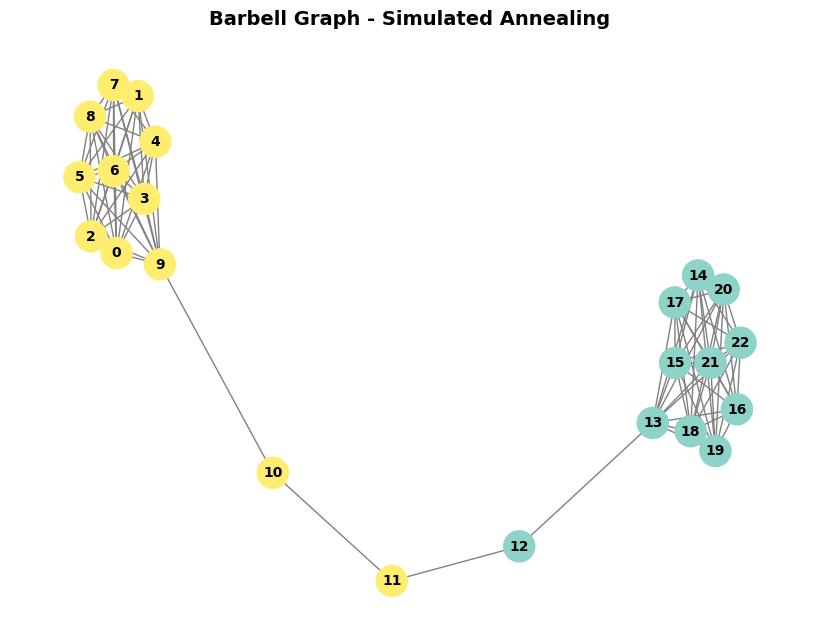

In [4]:
G2 = nx.barbell_graph(10, 3)

partition2 = run_sampler(
    G2,
    communities=2,
    resolution=1.0,
    time=200000,
    Tmax=200000,
    Tmin=2.0,
    steps=200000,
    updates=0,
)

modularity2 = calculate_modularity_nx(G2, partition2, resolution=1.0)
communities2 = partition_to_list(partition2)

print("=" * 70)
print("BARBELL GRAPH")
print("=" * 70)
print(f"Number of nodes: {G2.number_of_nodes()}")
print(f"Number of edges: {G2.number_of_edges()}")
print(f"Modularity: {modularity2:.6f}")
print(f"Number of detected communities: {len(communities2)}")
print()
for idx, community in enumerate(communities2):
    print(f"Community {idx}: {len(community)} nodes")
    print(f"  Nodes: {community}")
print("=" * 70)

visualize_partition(G2, partition2, "Barbell Graph - Simulated Annealing")

## Test 3: Caveman Graph

 Temperature        Energy    Accept   Improve     Elapsed   Remaining
     2.50000       -315.68    23.86%     1.57%     0:00:24     0:00:00C:\Users\Kacper\AppData\Local\Temp\ipykernel_24612\1323893553.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


CAVEMAN GRAPH
Number of nodes: 50
Number of edges: 225
Modularity: 0.777778
Number of detected communities: 5

Community 0: 10 nodes
  Nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Community 1: 10 nodes
  Nodes: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Community 2: 10 nodes
  Nodes: [20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Community 3: 10 nodes
  Nodes: [30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Community 4: 10 nodes
  Nodes: [40, 41, 42, 43, 44, 45, 46, 47, 48, 49]


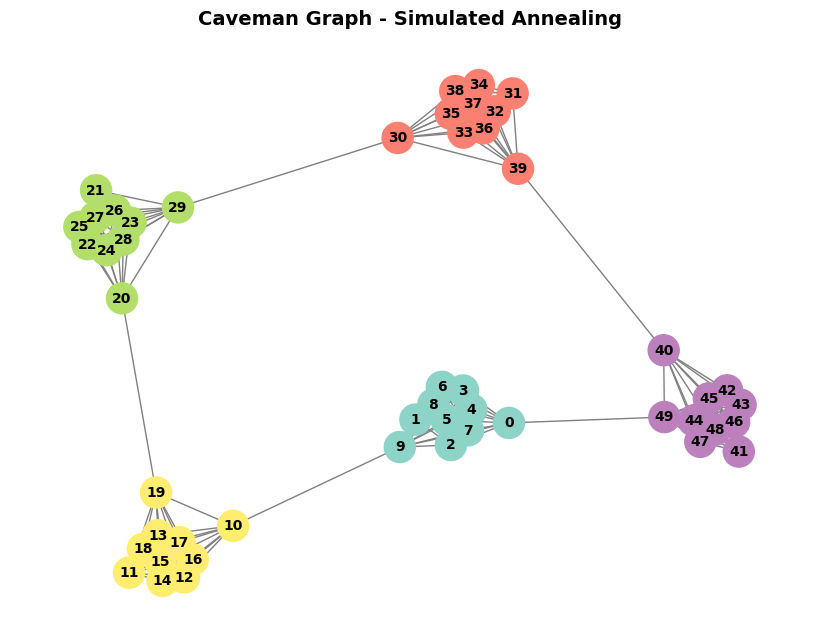

In [5]:
G3 = nx.connected_caveman_graph(5, 10)

partition3 = run_sampler(
    G3,
    communities=5,
    resolution=1.0,
    time=70000,
    Tmax=70000,
    Tmin=2.5,
    steps=70000,
    updates=100,
)

modularity3 = calculate_modularity_nx(G3, partition3, resolution=1.0)
communities3 = partition_to_list(partition3)

print("=" * 70)
print("CAVEMAN GRAPH")
print("=" * 70)
print(f"Number of nodes: {G3.number_of_nodes()}")
print(f"Number of edges: {G3.number_of_edges()}")
print(f"Modularity: {modularity3:.6f}")
print(f"Number of detected communities: {len(communities3)}")
print()
for idx, community in enumerate(communities3):
    print(f"Community {idx}: {len(community)} nodes")
    print(f"  Nodes: {community}")
print("=" * 70)

visualize_partition(G3, partition3, "Caveman Graph - Simulated Annealing")